In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/arabic-poetry-dataset-478-2017/all_poems.csv


In [3]:
! pip install arabic-reshaper python-bidi

In [4]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os
print(os.getcwd())


/kaggle/working


In [5]:
df = pd.read_csv('/kaggle/input/arabic-poetry-dataset-478-2017/all_poems.csv')

In [6]:
df = df[['poem_style', 'poem_text', 'poem_title', 'poet_cat', 'poet_name']]

In [7]:
df

,poem_style,poem_text,poem_title,poet_cat,poet_name
0,فصحى,عيناك غابتا نخيل ساعة السحر او شرفتان راح يناي...,أنشودة المطر,العراق,بدر شاكر السياب
1,فصحى,انا لا ازال و في يدي قدحي ياليل اين تفرق الشر...,أقداح و أحلام,العراق,بدر شاكر السياب
2,فصحى,علي مقلتيك ارتشفت النجوم وعانقت امالي الايبة ...,هوى واحد !,العراق,بدر شاكر السياب
3,فصحى,اساطير من حشرجات الزمان نسيج اليد البالية رواه...,أساطير,العراق,بدر شاكر السياب
4,فصحى,والتف حولك ساعداي ومال جيدك في اشتهاء كالزهرة ...,اللقاء الأخير,العراق,بدر شاكر السياب
...,...,...,...,...,...
58016,فصحى,لروح صهيل لا تحويه الاوقات ذنبك انك تمتد علي ا...,الوقت,سوريا,عز الدين اليوسف
58017,فصحى,اه لو اني ابني الشمس بعيني من طين هواء وسراب م...,الفلاح,سوريا,عز الدين اليوسف
58018,فصحى,في عينيك يا امي لماذا الدمع منتظم كعقد الءلء ا...,أمّي,سوريا,عز الدين اليوسف
58019,فصحى,النوم يوقظ طرفي الظامي علي لحن تموج من بعيد ار...,عن اللحن,سوريا,عز الدين اليوسف


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58021 entries, 0 to 58020
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   poem_style  58021 non-null  object
 1   poem_text   58020 non-null  object
 2   poem_title  58021 non-null  object
 3   poet_cat    58021 non-null  object
 4   poet_name   58021 non-null  object
dtypes: object(5)
memory usage: 2.2+ MB


In [9]:
df.describe()

,poem_style,poem_text,poem_title,poet_cat,poet_name
count,58021,58020,58021,58021,58021
unique,3,57693,56872,26,652
top,فصحى,اذا الرتبة العليا اتك اثابة وفاروق عالي الراس...,الشاعر,العصر العباسي,ابن الرومي
freq,57894,3,17,19417,2142


In [10]:
df.poet_cat.unique()

array(['العراق', 'سوريا', 'مصر', 'تونس', 'السعودية', 'لبنان', 'فلسطين',
       'اليمن', 'العصر الجاهلي', 'العصر الأندلسي', 'السودان', 'البحرين',
       'العصر الإسلامي', 'العصر العباسي', 'ليبيا', 'عمان', 'المغرب',
       'الجزائر', 'الإمارات', 'الأردن', 'الكويت', 'قطر', 'موريتانيا',
       'شعراء العراق والشام', 'أفغانستان', 'إيران'], dtype=object)

In [11]:
df['poet_name'].value_counts()

poet_name
ابن الرومي            2142
أبوالعلاء المعري      1593
ابن نباتة المصري      1534
جبران خليل جبران      1148
عبد الغني النابلسي    1115
                      ... 
الشنفرى                  1
عبيد بن الأبرص           1
عبدالكريم الطبال         1
سلمة بن عياض             1
أمل طنانة                1
Name: count, Length: 652, dtype: int64

In [12]:
df.isna().sum()

poem_style    0
poem_text     1
poem_title    0
poet_cat      0
poet_name     0
dtype: int64

In [13]:
df.drop_duplicates(inplace=True)
df.dropna(inplace=True)

<Axes: xlabel='poem_style', ylabel='count'>

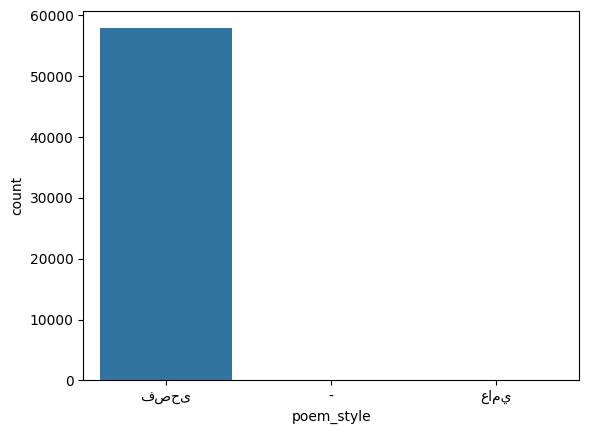

In [14]:
sns.countplot(x='poem_style', data=df)

In [15]:
df.shape

(58005, 5)

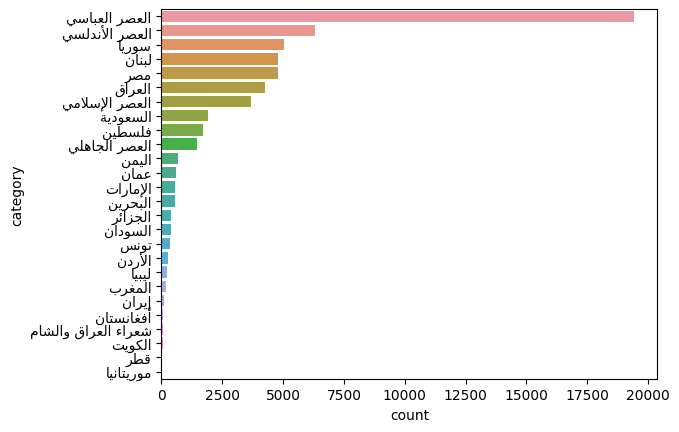

In [16]:
from bidi.algorithm import get_display
import arabic_reshaper
categories = df.poet_cat.value_counts()
res2 = {get_display(arabic_reshaper.reshape(k)): v for k,v in categories.items()}
df_cat = pd.DataFrame(res2.items(), columns=['category', 'count'])
df_cat.sort_values(by='count', ascending=False, inplace=True)
ax = sns.barplot(x="count", y="category", data=df_cat)

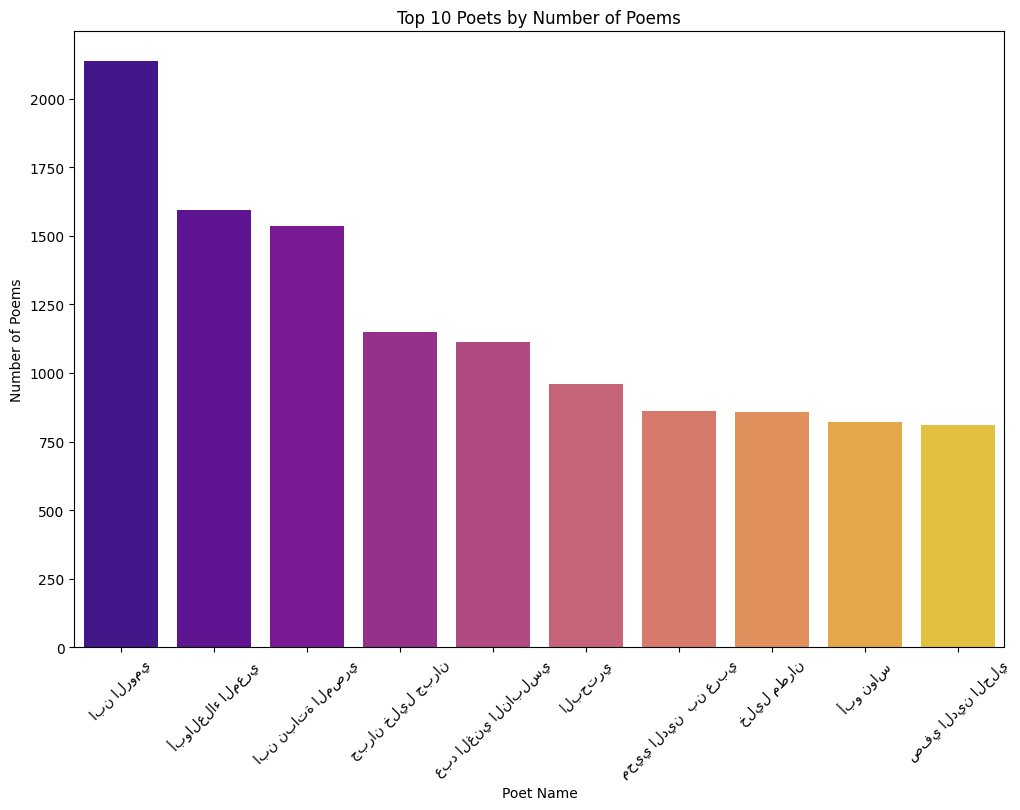

In [17]:
# Count the number of poems per poet
poet_counts = df['poet_name'].value_counts()
top_poets = poet_counts.head(10)

# Plot the top poets
plt.figure(figsize=(12, 8))
sns.barplot(x=top_poets.index, y=top_poets.values, palette='plasma')
plt.title('Top 10 Poets by Number of Poems')
plt.xlabel('Poet Name')
plt.ylabel('Number of Poems')
plt.xticks(rotation=45)
plt.show()

In [18]:
df[df['poet_name'] == 'نزار قباني']

,poem_style,poem_text,poem_title,poet_cat,poet_name
193,فصحى,1 لن تجعلوا من شعبنا شعب هنود حمر فنحن باقون ه...,منشورَاتٌ فِدَائيّة على جُدْرَانِ إسْرائيل,سوريا,نزار قباني
194,فصحى,من بحار النزيف جاء اليكم حاملا قلبه علي كفيه س...,هجم النفط مثل ذئب علينا,سوريا,نزار قباني
195,فصحى,لنفترق قليلا لخير هذا الحب يا حبيبي وخيرنا لنف...,أسألك الرحيلا,سوريا,نزار قباني
196,فصحى,صباح الخير يا حلوه صباح الخير يا قديستي الحلوه...,خمس رسائل إلى أمي,سوريا,نزار قباني
197,فصحى,اغضب كما تشاء واجرح احاسيسي كما تشاء حطم اواني...,إغضب !!,سوريا,نزار قباني
...,...,...,...,...,...
793,فصحى,كوني كوني امراة خطرة كي اتاكد -حين اضمك انك لس...,الشجرة,سوريا,نزار قباني
794,فصحى,الي متي اعتكف عنها ولا اعترف اضل الناس ولوني ب...,لا اعترف,سوريا,نزار قباني
795,فصحى,سميتك الجنوب يا لابسا عباءة الحسين وشمس كربلاء...,السمفونيه الجنوبيه الخامسه,سوريا,نزار قباني
796,فصحى,وكل ما سمعت عن حروبنا المظفرة وكرنا و فرنا وار...,قراءه ثانيه فى مقدمة ابن خلدون,سوريا,نزار قباني


In [19]:
# Length of each poem
df['poem_length'] = df['poem_text'].apply(lambda x: len(x.split()))

df

,poem_style,poem_text,poem_title,poet_cat,poet_name,poem_length
0,فصحى,عيناك غابتا نخيل ساعة السحر او شرفتان راح يناي...,أنشودة المطر,العراق,بدر شاكر السياب,509
1,فصحى,انا لا ازال و في يدي قدحي ياليل اين تفرق الشر...,أقداح و أحلام,العراق,بدر شاكر السياب,660
2,فصحى,علي مقلتيك ارتشفت النجوم وعانقت امالي الايبة ...,هوى واحد !,العراق,بدر شاكر السياب,264
3,فصحى,اساطير من حشرجات الزمان نسيج اليد البالية رواه...,أساطير,العراق,بدر شاكر السياب,222
4,فصحى,والتف حولك ساعداي ومال جيدك في اشتهاء كالزهرة ...,اللقاء الأخير,العراق,بدر شاكر السياب,264
...,...,...,...,...,...,...
58016,فصحى,لروح صهيل لا تحويه الاوقات ذنبك انك تمتد علي ا...,الوقت,سوريا,عز الدين اليوسف,87
58017,فصحى,اه لو اني ابني الشمس بعيني من طين هواء وسراب م...,الفلاح,سوريا,عز الدين اليوسف,50
58018,فصحى,في عينيك يا امي لماذا الدمع منتظم كعقد الءلء ا...,أمّي,سوريا,عز الدين اليوسف,80
58019,فصحى,النوم يوقظ طرفي الظامي علي لحن تموج من بعيد ار...,عن اللحن,سوريا,عز الدين اليوسف,36


In [20]:
# Most common words in poem texts (optional)
from collections import Counter
import re

# Tokenize and count words
all_words = ' '.join(df['poem_text'].dropna()).lower()
all_words = re.findall(r'\b\w+\b', all_words)
word_counts = Counter(all_words)

# Display the most common words
print(word_counts.most_common(10))

[('من', 219833), ('في', 216313), ('ما', 87334), ('علي', 87079), ('ان', 76196), ('و', 71351), ('لا', 67020), ('يا', 50248), ('الي', 42624), ('اذا', 40362)]


/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


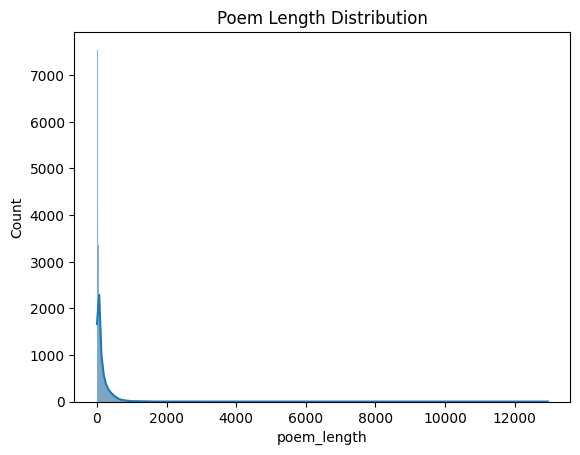

In [21]:
# Poem length distribution
sns.histplot(df['poem_length'], kde=True)
plt.title('Poem Length Distribution')
plt.show()

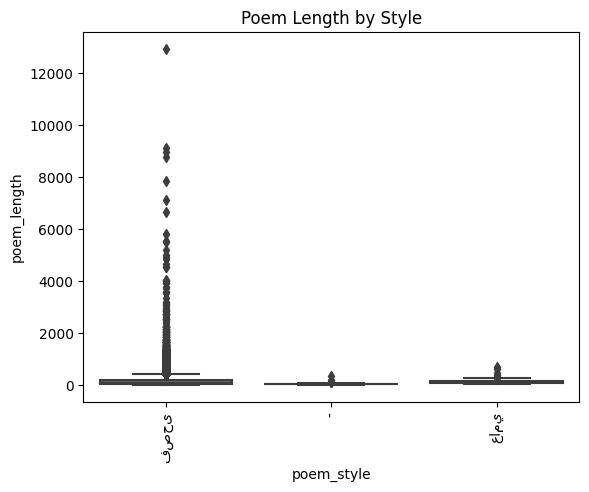

In [22]:
# Relationship between poem length and style
sns.boxplot(x='poem_style', y='poem_length', data=df)
plt.title('Poem Length by Style')
plt.xticks(rotation=90)
plt.show()

In [23]:
from sklearn.feature_extraction.text import CountVectorizer

# Function to extract n-grams
def get_ngrams(text, n=2):
    vectorizer = CountVectorizer(ngram_range=(n, n))
    X = vectorizer.fit_transform([text])
    ngram_counts = X.toarray().sum(axis=0)
    ngrams = vectorizer.get_feature_names_out()
    return sorted(zip(ngrams, ngram_counts), key=lambda x: x[1], reverse=True)

# Combine all poem texts into a single string
all_text = ' '.join(df['poem_text'].dropna()).lower()
# Extract and display bigrams (2-grams)
bigrams = get_ngrams(all_text, n=2)
print("Top 10 Bigrams:")
for bigram, count in bigrams[:10]:
    print(f"{bigram}: {count}")


Top 10 Bigrams:
اذا ما: 6778
في كل: 5956
من كل: 3732
ما كان: 2569
لم يكن: 2404
ما بين: 2033
من بعد: 2030
يا من: 2013
كل يوم: 1870
حتي اذا: 1684


In [24]:
import spacy

# Load the spaCy model
nlp = spacy.load('en_core_web_sm')

# Apply NER to a sample poem
doc = nlp(df['poem_text'].iloc[0])
for ent in doc.ents:
    print(ent.text, ent.label_)


راح ORG
الكروم وترقص ORG
غوريهما النجوم وتغرقان ORG
اسي شفيف ORG
وارتعاشة PERSON
فتستفيق ملء روحي PERSON
كنشوة الطفل PERSON
علي ORG
طفلا بات يهذي قبل ان ينام PERSON
جانب التل PERSON
نومة الحود PERSON
يجمع PERSON
حزن يبعث المطر ORG
تنشج المزاريب اذا انهمر PERSON
الوحيد فيه PERSON
المطر وعبر PERSON
الخليج CARDINAL
البروق سواحل العراق PERSON
كانه النشيج PERSON
اكاد اسمع العراق PERSON
الرعود ويخزن PERSON
السهول NORP
الواد من اثر اكاد اسمع ORG
المطر واسمع PERSON
وينثر الغلال فيه موسم ORG
الحصاد لتشبع PERSON
رحي تدور PERSON
كل قطرة من المطر حمراء PERSON
الزهر وكل دمعة PERSON
والعراة وكل قطرة تراق PERSON
كانه النشيج PERSON
وفي العراق PERSON
واسمع PERSON
كل قطرة من المطر حمراء PERSON
الزهر وكل دمعة PERSON
والعراة وكل قطرة تراق PERSON


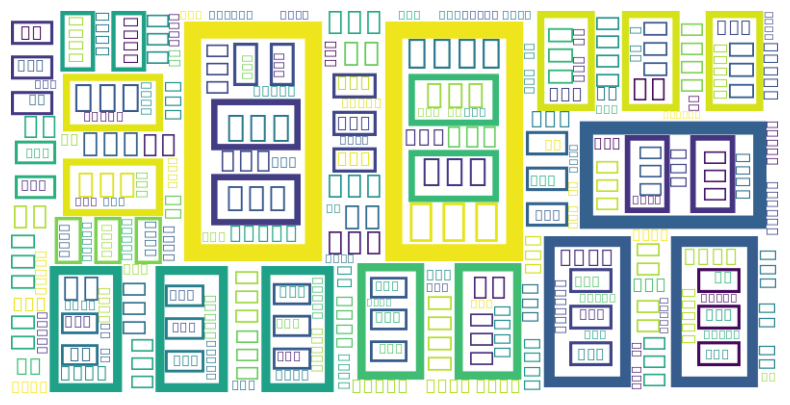

In [25]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all poem texts into a single string
all_text = ' '.join(df['poem_text'].dropna()).lower()

# Generate a word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)

# Display the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()


count    58005.000000
mean         0.001082
std          0.022151
min         -0.166667
25%          0.000000
50%          0.000000
75%          0.000000
max          0.500000
Name: sentiment, dtype: float64


/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


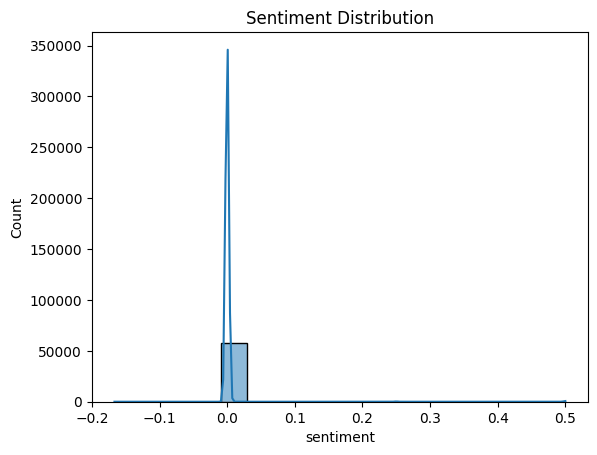

In [26]:
from textblob import TextBlob

# Function to calculate sentiment polarity
def get_sentiment(text):
    blob = TextBlob(text)
    return blob.sentiment.polarity

# Apply sentiment analysis
df['sentiment'] = df['poem_text'].apply(lambda x: get_sentiment(x))

# Summary statistics of sentiment
print(df['sentiment'].describe())

# Visualize the distribution of sentiment
sns.histplot(df['sentiment'], kde=True)
plt.title('Sentiment Distribution')
plt.show()


In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

# Vectorize the text data using TF-IDF
vectorizer = TfidfVectorizer(stop_words='english')
X = vectorizer.fit_transform(df['poem_text'].dropna())

# Perform KMeans clustering
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans.fit(X)

# Add cluster labels to the dataframe
df['cluster'] = kmeans.labels_

# Display poems in the same cluster
print(df[df['cluster'] == 0].head())


/opt/conda/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


   poem_style                                          poem_text  \
5        فصحى   اطلي علي طرفي الدامع خيالا من الكوكب الساطع ظ...   
53       فصحى  من مرضي من السرير الابيض من جاري انهار علي فرا...   
71       فصحى  الريح تلهث بالهجيرة كالجثام علي الاصيل و علي ا...   
77       فصحى   بلينا و ما تبلي النجوم الطوالع و يبقي اليتامي...   
78       فصحى  1- هياي كونغاي كونغاي ما زال ناقوس ابيك يقلق ا...   

          poem_title poet_cat        poet_name  poem_length  sentiment  \
5             أهواء    العراق  بدر شاكر السياب          986        0.0   
53           الوصية    العراق  بدر شاكر السياب          371        0.0   
71  غريب على الخليج    العراق  بدر شاكر السياب          646        0.0   
77     مرئية الآلهة    العراق  بدر شاكر السياب          441        0.0   
78    من رؤيا فوكاي    العراق  بدر شاكر السياب          934        0.0   

    cluster  
5         0  
53        0  
71        0  
77        0  
78        0  


In [28]:
new_data = df[(df['poet_cat'] == 'العصر العباسي') & (df['poem_style'] == 'فصحى')]
df2 = new_data.sample(n=200, random_state=42)  # random_state for reproducibility

In [29]:
def clean_text(text):
    # Remove punctuation only allow string or space
    text = re.sub(r'[^\w\s]', '', text)
    # Replace multiple spaces with a single space
    text = re.sub(r'\s+', ' ', text)
    # Remove numbers
    text= re.sub(r'\d+', '', text)
    text = re.sub(r'_', '', text)

    return text

In [30]:
df2['poem_text'] = df2['poem_text'].apply(clean_text)

In [31]:
import torch
import torch.nn as nn
from torch.nn import functional as F
torch.manual_seed(1337) # Robust 

In [32]:
def tokenize_sentence(sentence):
    # Tokenize the sentence into words
    return sentence.split()

In [33]:
# Assuming df2['poem_text'] contains the text data as before
text = ' '.join(df2['poem_text'].astype(str).tolist())

# Tokenize the concatenated text by words
tokens = tokenize_sentence(text)

# Find unique tokens (words) and sort them
unique_tokens = sorted(set(tokens))
vocab_size = len(unique_tokens)

# Create mappings
stoi = {word: i for i, word in enumerate(unique_tokens)}
itos = {i: word for i, word in enumerate(unique_tokens)}

# Define encode and decode functions
encode = lambda s: [stoi.get(word) for word in s]
decode = lambda l: ' '.join([itos.get(i) for i in l])


In [34]:
#Prepare data
encoded_tokens = encode(tokens)  # Encode the tokens (words)
data = torch.tensor(encoded_tokens, dtype=torch.long)

# Split data into train and validation sets
n = int(0.9 * len(data))  # 90% train, 10% validation
train_data = data[:n]
val_data = data[n:]

# Decode the encoded tokens back to text
decoded_text = decode(encoded_tokens)

In [35]:
# Print some information
print(f"Vocabulary size: {len(stoi)}")
print(f"Train data size: {len(train_data)}")
print(f"Validation data size: {len(val_data)}")

Vocabulary size: 12176
Train data size: 21590
Validation data size: 2399


In [36]:
def tokenize_sentence(sentence):
    # Tokenize the sentence into characters including spaces
    return list(sentence)

text = ' '.join(df2['poem_text'].astype(str).tolist())  
# Tokenize the concatenated text
tokens = tokenize_sentence(text)

# Find unique tokens and sort them
unique_tokens = sorted(set(tokens))
vocab_size = len(unique_tokens)

# Create mappings
stoi = {ch: i for i, ch in enumerate(unique_tokens)}
itos = {i: ch for i, ch in enumerate(unique_tokens)}

# Define encode and decode functions
encode = lambda s: [stoi.get(c) for c in s] 
decode = lambda l: ''.join([itos.get(i) for i in l])  

# Prepare data
encoded_tokens = encode(tokens)  # Encode the tokens
data = torch.tensor(encoded_tokens, dtype=torch.long)

# Split data into train and validation sets
n = int(0.9 * len(data))  # 90% train, 10% validation
train_data = data[:n]
val_data = data[n:]

# Decode the encoded tokens back to text
decoded_text = decode(encoded_tokens)

# Print some information
print(f"Vocabulary size: {len(stoi)}")
print(f"Train data size: {len(train_data)}")
print(f"Validation data size: {len(val_data)}")

Vocabulary size: 32
Train data size: 109265
Validation data size: 12141


In [37]:
# hyperparameters
batch_size = 64 # how many independent sequences will we process in parallel?
block_size = 256 # what is the maximum context length for predictions?
max_iters = 4000
eval_interval = 500
learning_rate = 0.001
device = 'cuda' if torch.cuda.is_available() else 'cpu'
eval_iters = 200
n_embd = 384
n_head = 6
n_layer = 6
dropout = 0.2

In [38]:
def get_batch(split):
    # generate a small batch of data of inputs x and targets y
    data = train_data if split == 'train' else val_data
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([data[i:i+block_size] for i in ix])
    y = torch.stack([data[i+1:i+block_size+1] for i in ix])
    x, y = x.to(device), y.to(device)
    return x, y

In [39]:
xb, yb = get_batch('train')

In [40]:
class Head(nn.Module):
    """ one head of self-attention """

    def __init__(self, head_size):
        super().__init__()
        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # input of size (batch, time-step, channels)
        # output of size (batch, time-step, head size)
        B,T,C = x.shape
        k = self.key(x)   # (B,T,hs)
        q = self.query(x) # (B,T,hs)
        # compute attention scores ("affinities")
        wei = q @ k.transpose(-2,-1) * k.shape[-1]**-0.5 # (B, T, hs) @ (B, hs, T) -> (B, T, T)
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf')) # (B, T, T)
        wei = F.softmax(wei, dim=-1) # (B, T, T)
        wei = self.dropout(wei)
        # perform the weighted aggregation of the values
        v = self.value(x) # (B,T,hs)
        out = wei @ v # (B, T, T) @ (B, T, hs) -> (B, T, hs)
        return out

class MultiHeadAttention(nn.Module):
    """ multiple heads of self-attention in parallel """

    def __init__(self, num_heads, head_size):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])
        self.proj = nn.Linear(head_size * num_heads, n_embd)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        out = self.dropout(self.proj(out))
        return out

class FeedFoward(nn.Module):
    """ a simple linear layer followed by a non-linearity """

    def __init__(self, n_embd):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.ReLU(), # GELU
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)

class Block(nn.Module):
    """ Transformer block: communication followed by computation """

    def __init__(self, n_embd, n_head):
        # n_embd: embedding dimension, n_head: the number of heads we'd like
        super().__init__()
        head_size = n_embd // n_head
        self.sa = MultiHeadAttention(n_head, head_size)
        self.ffwd = FeedFoward(n_embd)
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)

    def forward(self, x):
        x = x + self.sa(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x

class GPTLanguageModel(nn.Module):

    def __init__(self):
        super().__init__()
        # each token directly reads off the logits for the next token from a lookup table
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd)
        self.blocks = nn.Sequential(*[Block(n_embd, n_head=n_head) for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(n_embd) # final layer norm
        self.lm_head = nn.Linear(n_embd, vocab_size)
        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        B, T = idx.shape

        # idx and targets are both (B,T) tensor of integers
        tok_emb = self.token_embedding_table(idx) # (B,T,C)
        pos_emb = self.position_embedding_table(torch.arange(T, device=device)) # (T,C)
        x = tok_emb + pos_emb # (B,T,C)
        x = self.blocks(x) # (B,T,C)
        x = self.ln_f(x) # (B,T,C)
        logits = self.lm_head(x) # (B,T,vocab_size)

        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            logits = logits.view(B*T, C)
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits, targets)

        return logits, loss

    def generate(self, idx, max_new_tokens):
        # idx is (B, T) array of indices in the current context
        for _ in range(max_new_tokens):
            # crop idx to the last block_size tokens
            idx_cond = idx[:, -block_size:]
            # get the predictions
            logits, loss = self(idx_cond)
            # focus only on the last time step
            logits = logits[:, -1, :] # becomes (B, C)
            # apply softmax to get probabilities
            probs = F.softmax(logits, dim=-1) # (B, C)
            # sample from the distribution
            idx_next = torch.multinomial(probs, num_samples=1) # (B, 1)
            # append sampled index to the running sequence
            idx = torch.cat((idx, idx_next), dim=1) # (B, T+1)
        return idx

In [41]:
from sklearn.metrics import f1_score

@torch.no_grad()
def estimate_loss_and_metrics():
    out = {'loss': {}, 'accuracy': {}, 'f1_score': {}}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        all_predictions = []
        all_labels = []
        
        for k in range(eval_iters):
            X, Y = get_batch(split)
            logits, loss = model(X, Y)
            losses[k] = loss.item()
            
            # Get predictions from logits
            _, predicted = torch.max(logits, dim=-1)
            
            # Flatten the tensors to make them compatible with sklearn metrics
            all_predictions.extend(predicted.view(-1).cpu().numpy())
            all_labels.extend(Y.view(-1).cpu().numpy())
        
        # Calculate F1 score
        f1 = f1_score(all_labels, all_predictions, average='macro')

        # Store the mean loss, accuracy, and F1 score for this split
        accuracy = sum(p == l for p, l in zip(all_predictions, all_labels)) / len(all_labels)
        out['loss'][split] = losses.mean().item()
        out['accuracy'][split] = accuracy
        out['f1_score'][split] = f1
    
    model.train()
    return out


In [ ]:
# Initialize model
model = GPTLanguageModel()
m = model.to(device)

# Print the number of parameters in the model
print(sum(p.numel() for p in m.parameters()) / 1e6, 'M parameters')

# Create a PyTorch optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

for iter in range(max_iters):

    # Evaluate the loss, accuracy, and F1 score on train and val sets at intervals
    if iter % eval_interval == 0 or iter == max_iters - 1:
        metrics = estimate_loss_and_metrics()
        print(f"step {iter}: train loss {metrics['loss']['train']:.4f}, val loss {metrics['loss']['val']:.4f}")
        print(f"          train accuracy {metrics['accuracy']['train']:.4f}, val accuracy {metrics['accuracy']['val']:.4f}")
        print(f"          train F1 score {metrics['f1_score']['train']:.4f}, val F1 score {metrics['f1_score']['val']:.4f}")

    # Sample a batch of data
    xb, yb = get_batch('train')

    # Evaluate the loss
    logits, loss = model(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

10.763552 M parameters
step 0: train loss 3.5611, val loss 3.5641
          train accuracy 0.0186, val accuracy 0.0183
          train F1 score 0.0090, val F1 score 0.0089
step 500: train loss 2.5652, val loss 2.5920
          train accuracy 0.2775, val accuracy 0.2747
          train F1 score 0.0438, val F1 score 0.0451
step 1000: train loss 2.1572, val loss 2.3005
          train accuracy 0.3836, val accuracy 0.3640
          train F1 score 0.1388, val F1 score 0.1225
step 1500: train loss 1.8355, val loss 2.3196
          train accuracy 0.4560, val accuracy 0.3685
          train F1 score 0.2634, val F1 score 0.1511
step 2000: train loss 1.0965, val loss 2.7994
          train accuracy 0.6719, val accuracy 0.3420
          train F1 score 0.5817, val F1 score 0.1492


In [ ]:
#genrate poem from model
context = torch.zeros((1, 1), dtype=torch.long, device=device)
print(decode(m.generate(context, max_new_tokens=500)[0].tolist()))